# FOR DATA CONTAINS NUMERICALS ONLY

In [59]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [60]:
df=pd.read_csv('Housing_data.csv')
df.head()

,Price,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,16858,1629,1.0,3,0.76,180,0
1,26049,1344,2.0,3,0.92,13,0
2,26130,822,1.0,2,0.56,173,0
3,31113,1540,1.0,2,0.04,115,0
4,40932,1320,1.0,3,0.17,90,0


In [61]:
df.shape

(1047, 7)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price       1047 non-null   int64  
 1   LivingArea  1047 non-null   int64  
 2   Bathrooms   1047 non-null   float64
 3   Bedrooms    1047 non-null   int64  
 4   LotSize     1047 non-null   float64
 5   Age         1047 non-null   int64  
 6   Fireplace   1047 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 57.4 KB


In [63]:
df.dtypes

Price           int64
LivingArea      int64
Bathrooms     float64
Bedrooms        int64
LotSize       float64
Age             int64
Fireplace       int64
dtype: object

# 1) HANDLING MISSING VALUES

In [64]:
#checking:
df.isnull().sum()

Price         0
LivingArea    0
Bathrooms     0
Bedrooms      0
LotSize       0
Age           0
Fireplace     0
dtype: int64

# 2)REMOVE DUPLICATES

In [65]:
# Checking:
df.duplicated().sum()

np.int64(12)

In [66]:
df.drop_duplicates(inplace=True)

In [67]:
df.duplicated().sum()

np.int64(0)

# 3) OUTLIER DETECTION AND CAPPING

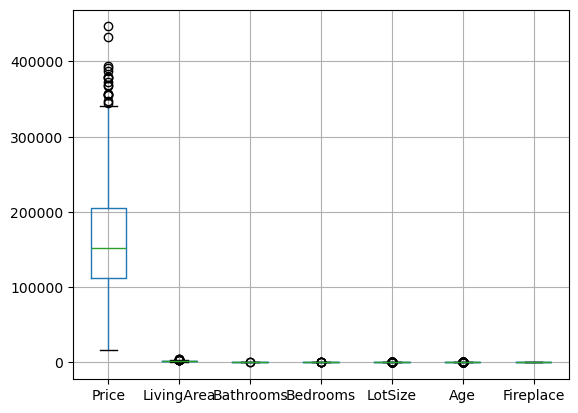

In [68]:
# Checking:
df.boxplot()
plt.show()

In [69]:
def outlier_capping(data,column):
    Q1=data[column].quantile(0.25)
    Q3=data[column].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    data[column]=data[column].apply(
        lambda x: lower if x  < lower else upper if x > upper else x
    )

In [70]:
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)
    

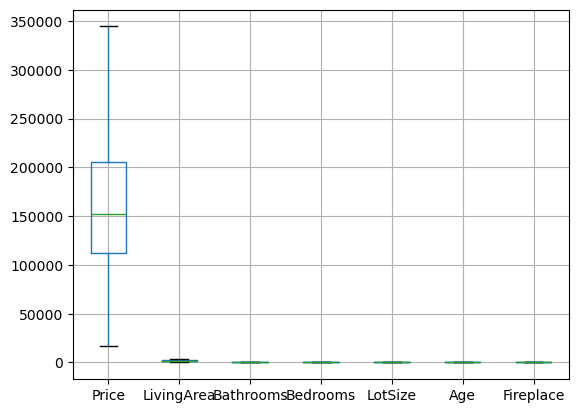

In [71]:
df.boxplot()
plt.show()

# 4) FEATURE SELECTION

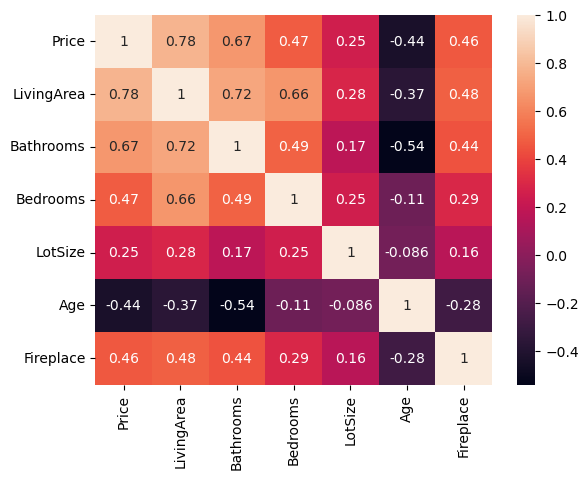

In [72]:
# correletion 
corr=df.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [73]:
corr['Price']

Price         1.000000
LivingArea    0.779461
Bathrooms     0.672573
Bedrooms      0.472767
LotSize       0.250458
Age          -0.438123
Fireplace     0.462812
Name: Price, dtype: float64

# 5) MULTICOLINEARITY

In [74]:
y=df['Price']
x=df.drop(columns='Price')
x.columns

Index(['LivingArea', 'Bathrooms', 'Bedrooms', 'LotSize', 'Age', 'Fireplace'], dtype='object')

In [75]:
vif=pd.DataFrame()
vif['Features']=x.columns
vif['VIF']=[variance_inflation_factor (x.values,i) for i in range (len(x.columns))]
vif.sort_values(by='VIF',ascending=False)

,Features,VIF
2,Bedrooms,29.100456
0,LivingArea,28.393716
1,Bathrooms,21.617158
3,LotSize,3.345417
5,Fireplace,3.304989
4,Age,2.471556


# 6) LABEL ENCODER

In [76]:
# HERE THERE IS NO COLUMN TO DO LABEL ENCODER( DONE ON CATEGORICAL COLUMN )

# 7) SCALER

In [77]:
df.head()

,Price,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,16858.0,1629.0,1.0,3.0,0.76,75.25,0
1,26049.0,1344.0,2.0,3.0,0.92,13.00,0
2,26130.0,822.0,1.0,2.0,0.56,75.25,0
3,31113.0,1540.0,1.0,2.0,0.04,75.25,0
4,40932.0,1320.0,1.0,3.0,0.17,75.25,0


In [78]:
st=StandardScaler()
x[['LivingArea','LotSize','Age']]=st.fit_transform(x[['LivingArea','LotSize','Age']])


In [79]:
x.head()

,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,-0.277590,1.0,3.0,0.937235,2.258368,0
1,-0.730058,2.0,3.0,1.437239,-0.488931,0
2,-1.558790,1.0,2.0,0.312231,2.258368,0
3,-0.418887,1.0,2.0,-1.312782,2.258368,0
4,-0.768161,1.0,3.0,-0.906529,2.258368,0


# FOR DATA CONTAINS NUMERICALS & CATEGORICAL

In [114]:
df=pd.read_csv('EDA_Practice_Dataset.csv')
df.head()

,Employee_ID,Age,Experience,Salary,Department,Education,City
0,1001,49,31.0,175660.0,HR,Masters,Chennai
1,1002,35,14.7,106297.0,HR,Bachelors,Delhi
2,1003,28,13.7,95046.0,IT,Bachelors,Delhi
3,1004,41,18.2,119424.0,Sales,PhD,Delhi
4,1005,39,17.2,100459.0,HR,Bachelors,Bangalore


In [115]:
df.shape

(102, 7)

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Employee_ID  102 non-null    int64  
 1   Age          102 non-null    int64  
 2   Experience   102 non-null    float64
 3   Salary       99 non-null     float64
 4   Department   100 non-null    object 
 5   Education    100 non-null    object 
 6   City         102 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 5.7+ KB


In [117]:
df.dtypes

Employee_ID      int64
Age              int64
Experience     float64
Salary         float64
Department      object
Education       object
City            object
dtype: object

# 1) HANDLING MISSING VALUES

In [118]:
# checking:
df.isnull().sum()

Employee_ID    0
Age            0
Experience     0
Salary         3
Department     2
Education      2
City           0
dtype: int64

In [119]:
df['Salary']=df['Salary'].fillna(df['Salary'].mean())
df['Department']=df['Department'].fillna(df['Department'].mode()[0])
df['Education']=df['Education'].fillna(df['Education'].mode()[0])

In [121]:
df.isnull().sum()

Employee_ID    0
Age            0
Experience     0
Salary         0
Department     0
Education      0
City           0
dtype: int64

# 2) REMOVING DUPLICATES

In [122]:
# Checking:
df.duplicated().sum()

np.int64(2)

In [123]:
df.drop_duplicates(inplace=True)

In [124]:
df.duplicated().sum()

np.int64(0)

# 3) OUTLIER DETECTION & CAPPING


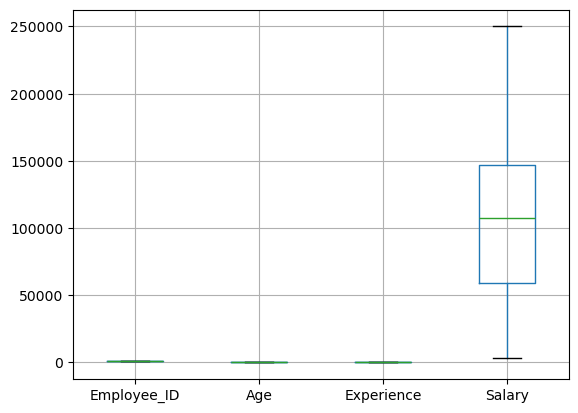

In [126]:
# Checking:
df.boxplot()
plt.show()

In [127]:
def outlier_capping(data,column):
    Q1=data[column].quantile(0.25)
    Q3=data[column].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    data[column]=data[column].apply(
        lambda x :  lower if x < lower else upper if x >  upper else x
    )

In [128]:
for col in ['Age','Experience','Salary']: # include all numerical column.
    outlier_capping(df,col)

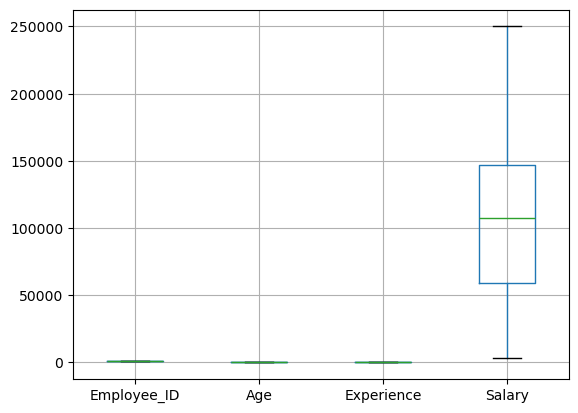

In [129]:
df.boxplot()
plt.show()

# 4) FEATURE SELECTION

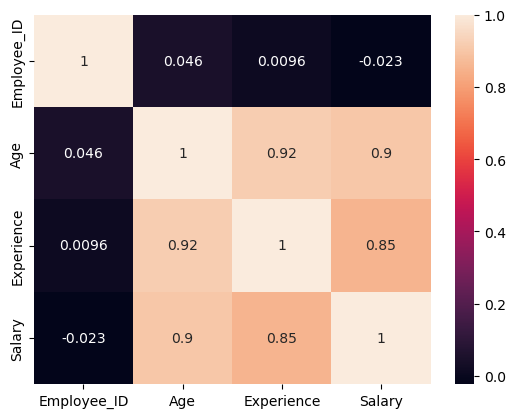

In [130]:
# CORRELATION----> for numerical column.
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.show()

In [132]:
corr['Salary']

Employee_ID   -0.023073
Age            0.902733
Experience     0.853670
Salary         1.000000
Name: Salary, dtype: float64

In [133]:
# ANNOVA TEST---> for categorical column.
for col in ['Department','Education','City']:
    data=[group['Salary'] for name , group in df.groupby(col)]
    f,p = f_oneway(*data)
    print(col,'p_value:',p)   # values ie ______<0.05

Department p_value: 0.96767373971431
Education p_value: 0.7078719752901912
City p_value: 0.35927207395440924


# 5) MULTICOLINERATITY

In [134]:
y=df['Salary']
x=df[['Age','Experience']]  # include all numerical column.
x.columns

Index(['Age', 'Experience'], dtype='object')

In [136]:
vif=pd.DataFrame()
vif['Features']=x.columns
vif['VIF']=[variance_inflation_factor(x.values,i) for i in range (len(x.columns))]
vif.sort_values(by='VIF',ascending=False)

,Features,VIF
0,Age,9.095373
1,Experience,9.095373


# 6) LABELENCODER

In [138]:
df.dtypes

Employee_ID      int64
Age              int64
Experience     float64
Salary         float64
Department      object
Education       object
City            object
dtype: object

In [139]:
le= LabelEncoder()
df['Department']=le.fit_transform(df['Department'])
df['Education']=le.fit_transform(df['Education'])
df['City']=le.fit_transform(df['City'])

In [141]:
df.head()

,Employee_ID,Age,Experience,Salary,Department,Education,City
0,1001,49,31.0,175660.0,1,1,1
1,1002,35,14.7,106297.0,1,0,2
2,1003,28,13.7,95046.0,2,0,2
3,1004,41,18.2,119424.0,3,2,2
4,1005,39,17.2,100459.0,1,0,0


# 7) SCALER

In [143]:
# for scaling not do on target.
st=StandardScaler()
df[['Age','Experience']]=st.fit_transform(df[['Age','Experience']])
df.head()

,Employee_ID,Age,Experience,Salary,Department,Education,City
0,1001,1.123174,1.273816,175660.0,1,1,1
1,1002,-0.238249,-0.216936,106297.0,1,0,2
2,1003,-0.918960,-0.308394,95046.0,2,0,2
3,1004,0.345218,0.103164,119424.0,3,2,2
4,1005,0.150729,0.011707,100459.0,1,0,0
